### Introduction

This notebook is my excercise with to purposes: learn Cirq and learn quantum error correction.

It is based on material in Chapter 10 of "Quantum Computation and Quantum Informaton" by Nielsen and Chuang.

**Warning.** Cells with charts will take long time to run.

### The problem

Suppose we have noisy quantum channel, which with probability $p$ changes transmitted qubit in a certain way. We have qubit and we want to pass it through this channel. We can use perfect (not-faulty) gates. We are allowed to encode given qubit into several qubits. Each of them is transmitted throw noisy channel. Then we can decode resulting qubit and we have to present one qubit. State of this qubit should be exactly the same as state of qubit we started with.

For beginning, noisy channel will apply bit-flip (i.e. X gate) with probability p, later we will consider other types of noise.

### The framework

There is qubit $| \psi >$. We allowed to "encode" it, by applying certain cirquit which produces one or more qubits.
Then these qubits are passed (independently) throw faulty channel. Then we allowed to "decode" result by applying another circuit to received cubits. It should producr one qubit. Finally, we check whether this is the same qubit as the one we started with. We repeat this many times with different (random) $| \psi >$ and measure error rate $p_1$. We will change $p_0$ and see how $p_1$ changes.

Let's build this framework and test it with no encoding-decoding. Obviosly, we expect $p_1=p_0$.


**How do we generate initial state?**

Any qubit state corresponds to a point on Bloch sphere. Let's generate random $\theta \in [0, \pi]$ and $\phi \in [0, 2 \pi]$. Then state is $ | \psi\rangle= \cos(\theta/2) |0 \rangle + e^{i \phi} \sin(\theta/2) |1 \rangle$. To get it from 
$| 0 \rangle$, apply gate defined by unitary matrix:

$$\begin{pmatrix}
   \cos(\frac{\theta}{2}) & -\sin(\frac{\theta}{2}) \\
   e^{i \phi} \sin(\frac{\theta}{2}) & e^{i \phi} \cos(\frac{\theta}{2})
  \end{pmatrix} $$
  
Cartesian coordinates of this state on the bloch sphere are $(\sin(\theta) \cos(\phi), \sin(\theta) \sin(\phi), \cos(\theta))$.

Code below demonstarted experiment with no error correcion.

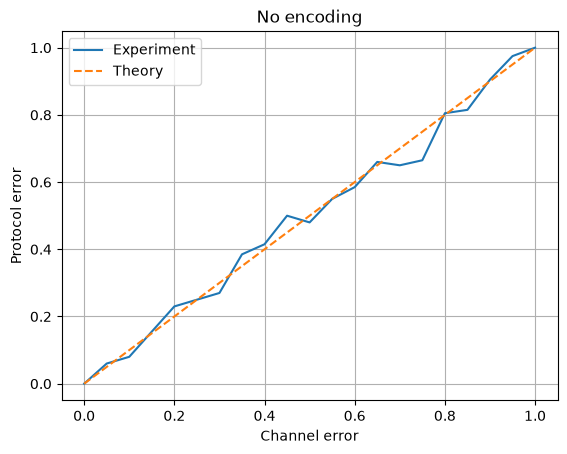

Time: 2.31s


In [1]:
from error_correction.protocols import NoEncodingProtocol
from error_correction.utils import plot_errors, test_protocol_once

plot_errors(NoEncodingProtocol(), num_experiments=200, theoretical=lambda x: x)